# Shared variance: cognitive parameters vs. symptom surveys — a CCA ladder with SHARP inference

**Question.** How much shared variance between the fitted cognitive-task parameters and the symptom surveys generalizes to held-out subjects, and does added model flexibility help?

**Ladder of methods** (least → most flexible), all ending in a linear CCA so canonical correlations are ordered and comparable:
- `raw` — regularized linear CCA on standardized raw features (baseline)
- `kernel` — kernel CCA (RBF)
- `deep` — Deep CCA (trained MLP encoders) + linear CCA on the learned representations
- `fm` — frozen tabular foundation-model (TabPFN v2) embeddings + linear CCA
- `fm_deep` — **TabPFN fine-tuned jointly with a deep CCA head** (disjoint support/query split + validation early stopping), then linear CCA on the fine-tuned representations

**Inference — SHARP test.** CV fold statistics are not independent, so naive CIs / repeated-split intervals and paired fold tests inflate false positives (Zeng et al. 2026, bioRxiv 2026.05.17.724301). SHARP splits subjects into two **disjoint** halves per repetition (stratified by `backfilled_prolific_screen_group`), runs K-fold CV within each, and uses the within-repetition independence of the two halves to get valid per-arm CIs and valid paired arm comparisons. A within-strata permutation null (matched statistic) gives the above-chance test.

**Compute.** The heavy multi-GPU work runs in `scripts/run_sharp_ladder.py` (distributed across all GPUs via `cogmood_analysis.sharp_parallel`), which checkpoints `data/exploratory/sharp_ladder_results.pkl`. This notebook just loads and visualizes that file.

```
uv run python scripts/run_sharp_ladder.py            # full run (all GPUs)
SV_QUICK=1 uv run python scripts/run_sharp_ladder.py # fast smoke
```

In [1]:
import pickle
import itertools
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_context("notebook")
RESULTS = Path("../data/exploratory/sharp_ladder_results.pkl")
R = pickle.loads(RESULTS.read_bytes())
ARMS = R["arms"]
PERM_DONE = [a for a in ARMS if a in R["perms"]]
print(("QUICK" if R["quick"] else "FULL"), f"run | N={R['n_subjects']} | J={R['J']} K={R['K']}")
print("permutations per arm:", R["n_perm"])
print("permutation nulls available for:", PERM_DONE)
print(f"View A (cognitive): {len(R['a_columns'])} cols | View B (symptom): {len(R['b_columns'])} cols")

FULL run | N=1399 | J=30 K=5
permutations per arm: {'raw': 1000, 'kernel': 1000, 'deep': 100, 'fm': 100, 'fm_deep': 50, 'tabfm': 100, 'tabfm_deep': 50}
permutation nulls available for: ['raw', 'kernel', 'deep', 'fm', 'fm_deep', 'tabfm', 'tabfm_deep']
View A (cognitive): 30 cols | View B (symptom): 20 cols


## 1. Per-arm held-out canonical correlation with valid SHARP 95% CIs

In [2]:
cis, perms = R["cis"], R["perms"]
print(f"{'arm':8s} {'held-out r':>11s} {'95% CI':>20s} {'shared var':>11s} {'rho':>6s} {'p_perm':>8s}")
for a in ARMS:
    c = cis[a]
    pp = f"{perms[a]['p']:.4f}" if a in perms else "   --"
    print(f"{a:8s} {c['mean']:>11.3f}  [{c['lo']:+.3f},{c['hi']:+.3f}] {c['shared_variance']:>11.4f} {c['rho']:>6.2f} {pp:>8s}")

arm       held-out r               95% CI  shared var    rho   p_perm
raw            0.093  [+0.063,+0.123]      0.0086   0.22   0.0080
kernel         0.093  [+0.041,+0.146]      0.0087   0.32   0.0060
deep           0.068  [+0.047,+0.089]      0.0046   0.18   0.2376
fm             0.069  [+0.043,+0.094]      0.0047   0.22   0.7723
fm_deep        0.068  [+0.054,+0.082]      0.0046   0.05   1.0000
tabfm          0.080  [+0.043,+0.117]      0.0064   0.31   0.1881
tabfm_deep       0.076  [+0.070,+0.081]      0.0057   0.00   0.3529


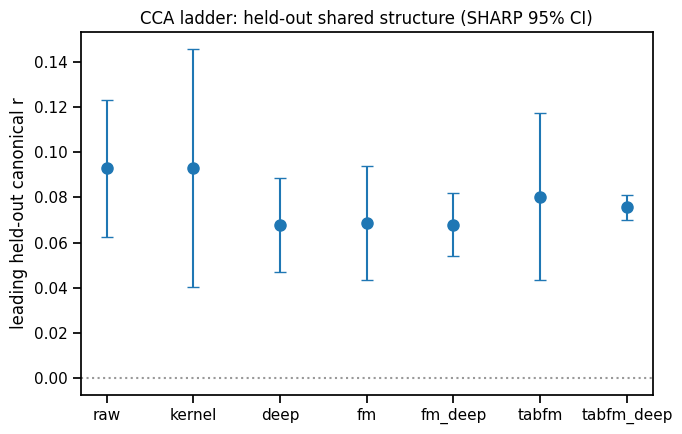

In [3]:
# Ladder plot: leading held-out canonical r with SHARP 95% CI
fig, ax = plt.subplots(figsize=(7, 4.5))
x = np.arange(len(ARMS))
means = [cis[a]['mean'] for a in ARMS]
los = [cis[a]['mean'] - cis[a]['lo'] for a in ARMS]
his = [cis[a]['hi'] - cis[a]['mean'] for a in ARMS]
ax.errorbar(x, means, yerr=[los, his], fmt='o', capsize=4, ms=8, color='C0')
ax.axhline(0, ls=':', color='0.6')
ax.set_xticks(x); ax.set_xticklabels(ARMS)
ax.set_ylabel('leading held-out canonical r')
ax.set_title('CCA ladder: held-out shared structure (SHARP 95% CI)')
plt.tight_layout(); plt.show()

## 2. Pairwise SHARP comparisons (which rung wins?)

Valid fold-dependence-aware test on the paired per-half difference in held-out canonical r.

comparison                 diff       z        p
raw vs kernel            -0.000   -0.02   0.9876
raw vs deep              +0.025   +1.38   0.1676
raw vs fm                +0.024   +1.53   0.1272
raw vs fm_deep           +0.025   +1.30   0.1945
raw vs tabfm             +0.013   +1.84   0.0664
raw vs tabfm_deep        +0.017   +3.90   0.0001
kernel vs deep           +0.025   +1.04   0.2983
kernel vs fm             +0.025   +0.87   0.3843
kernel vs fm_deep        +0.025   +0.83   0.4074
kernel vs tabfm          +0.013   +0.54   0.5905
kernel vs tabfm_deep     +0.017   +0.76   0.4467
deep vs fm               -0.001   -0.05   0.9582
deep vs fm_deep          -0.000   -0.02   0.9864
deep vs tabfm            -0.012   -0.63   0.5310
deep vs tabfm_deep       -0.008   -2.20   0.0280
fm vs fm_deep            +0.001   +0.05   0.9632
fm vs tabfm              -0.012   -0.48   0.6318
fm vs tabfm_deep         -0.007   -1.68   0.0930
fm_deep vs tabfm         -0.012   -0.80   0.4264
fm_deep vs tabfm_dee

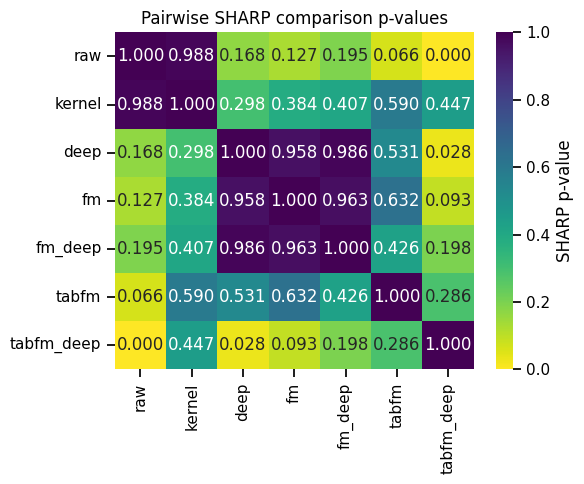

In [4]:
comparisons = R["comparisons"]
print(f"{'comparison':22s} {'diff':>8s} {'z':>7s} {'p':>8s}")
for (a1, a2) in itertools.combinations(ARMS, 2):
    c = comparisons[f"{a1}_vs_{a2}"]
    print(f"{a1+' vs '+a2:22s} {c['diff']:>+8.3f} {c['z']:>+7.2f} {c['p']:>8.4f}")

P = np.ones((len(ARMS), len(ARMS)))
for (a1, a2) in itertools.combinations(ARMS, 2):
    c = comparisons[f"{a1}_vs_{a2}"]
    i, j = ARMS.index(a1), ARMS.index(a2)
    P[i, j] = P[j, i] = c['p']
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(P, annot=True, fmt='.3f', xticklabels=ARMS, yticklabels=ARMS,
            cmap='viridis_r', vmin=0, vmax=1, cbar_kws={'label': 'SHARP p-value'}, ax=ax)
ax.set_title('Pairwise SHARP comparison p-values')
plt.tight_layout(); plt.show()

## 3. Above-chance test: within-strata permutation null

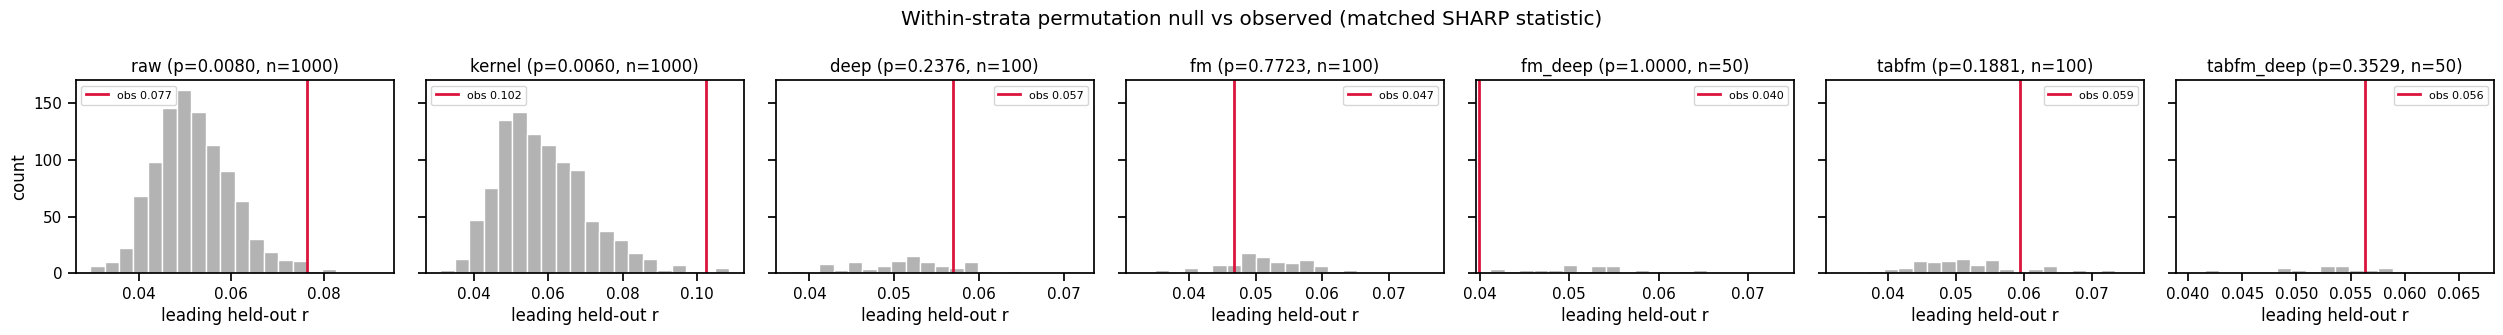

In [5]:
if PERM_DONE:
    fig, axes = plt.subplots(1, len(PERM_DONE), figsize=(3.6 * len(PERM_DONE), 3.4), sharey=True)
    if len(PERM_DONE) == 1:
        axes = [axes]
    for ax, a in zip(axes, PERM_DONE):
        out = perms[a]
        ax.hist(out['null'], bins=20, color='0.7', edgecolor='white')
        ax.axvline(out['observed'], color='crimson', lw=2, label=f"obs {out['observed']:.3f}")
        ax.set_title(f"{a} (p={out['p']:.4f}, n={R['n_perm'][a]})")
        ax.set_xlabel('leading held-out r'); ax.legend(fontsize=8)
    axes[0].set_ylabel('count')
    plt.suptitle('Within-strata permutation null vs observed (matched SHARP statistic)')
    plt.tight_layout(); plt.show()
else:
    print('No permutation nulls in the results file yet.')

## 4. Summary

Read off the tables/plots above:
- **Per-arm** held-out leading canonical r with **SHARP 95% CI**, implied shared variance (r²), and within-strata permutation p.
- **Pairwise** SHARP tests: whether any flexible arm (kernel / deep / fm / fm_deep) significantly beats the linear `raw` baseline — i.e. whether nonlinearity / the foundation model raises the *generalizable* ceiling.

**Reporting language.** Estimates are *generalizable* (held-out) shared variance with valid SHARP uncertainty (fold-dependence-aware), not in-sample correlations; naive across-fold/repeated-split CIs are invalid and not reported (Zeng et al. 2026). The ladder brackets the achievable ceiling under linear, kernel, deep, FM-embedding, and jointly-fine-tuned-FM CCA; the maximum across rungs is a model/representation-conditional estimate, not an absolute maximum. Analysis is on the complete-case sample, stratified by `backfilled_prolific_screen_group`.